In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix
import warnings
import pickle

In [4]:
df=pd.read_csv(r'/content/PS_20174392719_1491204439457_log.csv')

In [5]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
206149,13,PAYMENT,1562.19,C924173775,1312740.12,1311177.93,M113098452,0.0,0.00,0.0,0.0
206150,13,TRANSFER,26029.23,C955702923,11701.00,0.00,C1593503248,0.0,26029.23,0.0,0.0
206151,13,PAYMENT,5931.93,C1513578873,456824.00,450892.07,M1133902925,0.0,0.00,0.0,0.0
206152,13,PAYMENT,18011.97,C674603509,450892.07,432880.11,M649670910,0.0,0.00,0.0,0.0


In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206154 entries, 0 to 206153
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            206154 non-null  int64  
 1   type            206154 non-null  object 
 2   amount          206154 non-null  float64
 3   nameOrig        206154 non-null  object 
 4   oldbalanceOrg   206154 non-null  float64
 5   newbalanceOrig  206154 non-null  float64
 6   nameDest        206154 non-null  object 
 7   oldbalanceDest  206153 non-null  float64
 8   newbalanceDest  206153 non-null  float64
 9   isFraud         206153 non-null  float64
 10  isFlaggedFraud  206153 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 17.3+ MB


<Axes: ylabel='amount'>

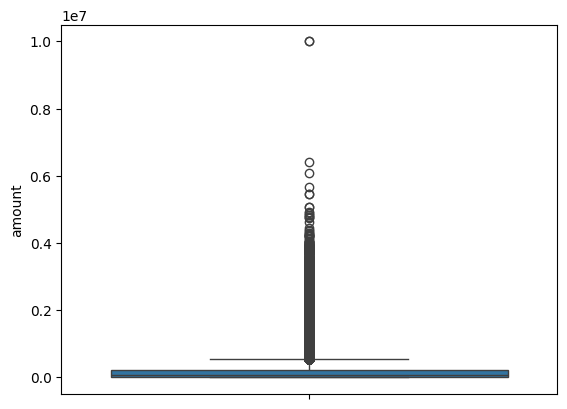

In [9]:
sns.boxplot(df['amount'])

In [10]:
from scipy import stats
print(stats.mode(df['amount']))
print(np.mean(df['amount']))

ModeResult(mode=np.float64(1813.69), count=np.int64(3))
180720.2568522561


In [11]:
q1 = np.quantile(df['amount'],0.25)
q3 = np.quantile(df['amount'],0.75)

IQR = q3-q1

upper_bound = q3+(1.5*IQR)
lower_bound = q1-(1.5*IQR)

print('q1 :',q1)
print('q3 :',q3)
print('IQR :',IQR)
print('Upper Bound :',upper_bound)
print('Lower Bound :',lower_bound)
print('Skewed data :',len(df[df['amount']>upper_bound]))
print('Skewed data :',len(df[df['amount']<lower_bound]))

q1 : 12114.6975
q3 : 229457.6725
IQR : 217342.97499999998
Upper Bound : 555472.135
Lower Bound : -313899.76499999996
Skewed data : 12236
Skewed data : 0


In [12]:
def transformationPlot(feature):
  plt.figure(figsize=(12,5))
  plt.subplot(1,2,1)
  sns.histplot(feature, kde=True)
  plt.subplot(1,2,2)
  stats.probplot(feature, plot=plt)

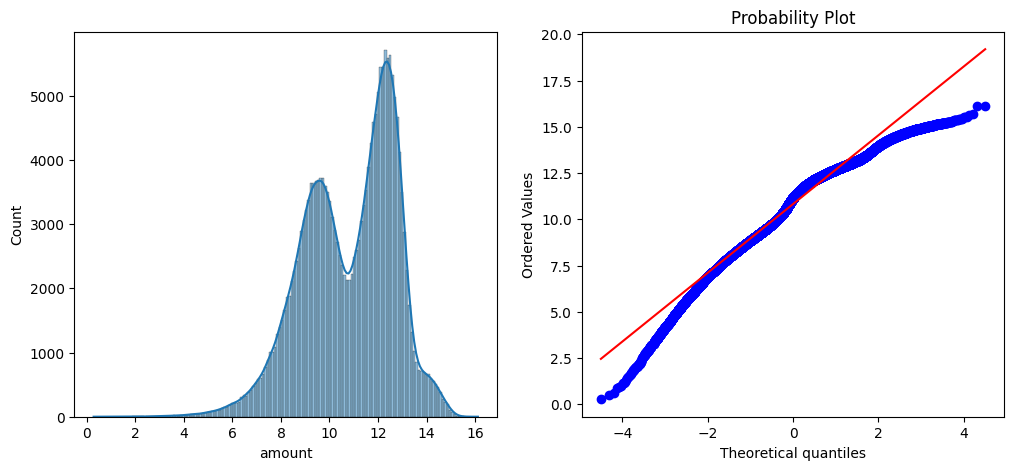

In [13]:
transformationPlot(np.log1p(df['amount']))

In [14]:
df['amount']=np.log(df['amount'])

In [15]:
from sklearn.preprocessing import LabelEncoder

la = LabelEncoder()
df['type' ] = la.fit_transform(df['type'])

In [16]:
df['type'].value_counts()

,count
type,
3,75362
1,68797
0,43005
4,17280
2,1710


In [17]:
x = df.drop('isFraud',axis=1)
y = df['isFraud' ]

In [18]:
x

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud
0,1,3,9.194174,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0.0
1,1,3,7.530630,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0.0
2,1,4,5.198497,C1305486145,181.00,0.00,C553264065,0.0,0.00,0.0
3,1,1,5.198497,C840083671,181.00,0.00,C38997010,21182.0,0.00,0.0
4,1,3,9.364617,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...
206149,13,3,7.353844,C924173775,1312740.12,1311177.93,M113098452,0.0,0.00,0.0
206150,13,4,10.166975,C955702923,11701.00,0.00,C1593503248,0.0,26029.23,0.0
206151,13,3,8.688105,C1513578873,456824.00,450892.07,M1133902925,0.0,0.00,0.0
206152,13,3,9.798792,C674603509,450892.07,432880.11,M649670910,0.0,0.00,0.0


In [19]:
y

,isFraud
0,0.0
1,0.0
2,1.0
3,1.0
4,0.0
...,...
206149,0.0
206150,0.0
206151,0.0
206152,0.0


In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test,y_train, y_test=train_test_split(x,y,random_state=0,test_size=0.2)

print(x_train.shape)
print(x_test.shape)
print(y_test.shape)
print(y_train.shape)

(164923, 10)
(41231, 10)
(41231,)
(164923,)


In [21]:
df.dropna(inplace=True)
# Handle -inf values in 'amount' column resulting from np.log(0)
# Replace them with NaN, then drop rows with NaNs
# This ensures that all numerical data passed to the model is finite.
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

x = df.drop(['isFraud', 'nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)
y = df['isFraud']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0, test_size=0.2)

print(x_train.shape)
print(x_test.shape)
print(y_test.shape)
print(y_train.shape)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)

y_test_predict1 = rfc.predict(x_test)
test_accuracy = accuracy_score(y_test, y_test_predict1)
print(f"Test Accuracy: {test_accuracy}")

(164922, 7)
(41231, 7)
(41231,)
(164922,)
Test Accuracy: 0.9994421673013024


In [22]:
y_train_predict1=rfc.predict(x_train)
train_accuracy=accuracy_score(y_train,y_train_predict1)
train_accuracy

1.0

In [23]:
pd.crosstab(y_test,y_test_predict1)

col_0,0.0,1.0
isFraud,,
0.0,41197,1
1.0,22,11


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_predict1))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     41198
         1.0       0.92      0.33      0.49        33

    accuracy                           1.00     41231
   macro avg       0.96      0.67      0.74     41231
weighted avg       1.00      1.00      1.00     41231



In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dtc = DecisionTreeClassifier()
dtc.fit(x_train, y_train)

y_test_predict2 = dtc.predict(x_test)
test_accuracy = accuracy_score(y_test, y_test_predict2)
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.9993208993233247


In [26]:
y_train_predict2=dtc.predict(x_train)
train_accuracy=accuracy_score(y_train,y_train_predict2)
train_accuracy

1.0

In [27]:
pd.crosstab(y_test,y_test_predict2)

col_0,0.0,1.0
isFraud,,
0.0,41187,11
1.0,17,16


In [28]:
print(classification_report(y_test, y_test_predict2))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     41198
         1.0       0.59      0.48      0.53        33

    accuracy                           1.00     41231
   macro avg       0.80      0.74      0.77     41231
weighted avg       1.00      1.00      1.00     41231



In [29]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

etc = ExtraTreesClassifier()
etc.fit(x_train, y_train)

y_test_predict3 = etc.predict(x_test)
test_accuracy = accuracy_score(y_test, y_test_predict3)
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.9993208993233247


In [30]:
y_train_predict3=etc.predict(x_train)
train_accuracy=accuracy_score(y_train,y_train_predict3)
train_accuracy

1.0

In [31]:
pd.crosstab(y_test,y_test_predict3)

col_0,0.0,1.0
isFraud,,
0.0,41197,1
1.0,27,6


In [32]:
print(classification_report(y_test, y_test_predict3))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     41198
         1.0       0.86      0.18      0.30        33

    accuracy                           1.00     41231
   macro avg       0.93      0.59      0.65     41231
weighted avg       1.00      1.00      1.00     41231



In [33]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svc = SVC()
svc.fit(x_train, y_train)

y_test_predict4 = svc.predict(x_test)
test_accuracy = accuracy_score(y_test, y_test_predict4)
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.9992238849409425


In [34]:
y_train_predict4=svc.predict(x_train)
train_accuracy=accuracy_score(y_train,y_train_predict4)
train_accuracy

0.9992966371981906

In [35]:
pd.crosstab(y_test,y_test_predict4)

col_0,0.0,1.0
isFraud,,
0.0,41198,0
1.0,32,1


In [36]:
print(classification_report(y_test, y_test_predict4))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     41198
         1.0       1.00      0.03      0.06        33

    accuracy                           1.00     41231
   macro avg       1.00      0.52      0.53     41231
weighted avg       1.00      1.00      1.00     41231



In [37]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [40]:
from sklearn.preprocessing import LabelEncoder

la = LabelEncoder()
y_train1=la.fit_transform(y_train)
y_test1=la.transform(y_test)

In [41]:
y_train1

array([0, 0, 0, ..., 0, 0, 0])

In [42]:
y_test1

array([0, 0, 0, ..., 0, 0, 0])

In [46]:
import xgboost as xgb
xgb1 = xgb.XGBClassifier()
xgb1.fit(x_train, y_train1)

y_predict5 = xgb1.predict(x_test)
test_accuracy = accuracy_score(y_test1, y_predict5)
print(f"Test Accuracy:{test_accuracy}")

Test Accuracy:0.9995149280880891


In [48]:
y_train5=xgb1.predict(x_train)
train_accuracy=accuracy_score(y_train1,y_train5)
print(f"Train Accuracy:{train_accuracy}")

Train Accuracy:0.9999818095827119


In [50]:
pd.crosstab(y_test1,y_predict5)

col_0,0,1
row_0,,
0,41196,2
1,18,15


In [52]:
print(classification_report(y_test1, y_predict5))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     41198
           1       0.88      0.45      0.60        33

    accuracy                           1.00     41231
   macro avg       0.94      0.73      0.80     41231
weighted avg       1.00      1.00      1.00     41231



In [57]:
def compareModel():
  print("train accuracy for rfc", accuracy_score(y_train_predict1,y_train))
  print("test accuracy for rfc", accuracy_score(y_test_predict1,y_test))
  print("train accuracy for dtc",accuracy_score(y_train_predict2,y_train))
  print("test accuracy for dtc", accuracy_score(y_test_predict2,y_test))
  print("train accuracy for etc",accuracy_score(y_train_predict3,y_train))
  print("test accuracy for etc", accuracy_score(y_test_predict3,y_test))
  print("train accuracy for svc",accuracy_score(y_train_predict4,y_train))
  print("test accuracy for svcc",accuracy_score(y_test_predict4,y_test))
  print("train accuracy for xgb1",accuracy_score(y_train5,y_train1))
  print("test accuracy for xgb1", accuracy_score(y_predict5,y_test1))

In [58]:
compareModel()

train accuracy for rfc 1.0
test accuracy for rfc 0.9994421673013024
train accuracy for dtc 1.0
test accuracy for dtc 0.9993208993233247
train accuracy for etc 1.0
test accuracy for etc 0.9993208993233247
train accuracy for svc 0.9992966371981906
test accuracy for svcc 0.9992238849409425
train accuracy for xgb1 0.9999818095827119
test accuracy for xgb1 0.9995149280880891


In [59]:
import pickle

In [60]:
pickle.dump(svc,open('payments.pkl','wb'))